Proyecto Hackathon 1: **Cacao Ancestral CDMX — Asistente de Operaciones y BrandCore**

Este proyecto implementa el pipeline de producción del Módulo 1 adaptado a un marca Cacao Ancestral CDMX (marca artesanal de chocolates, CDMX):

Paso 1: Instalación del entorno y dependencias

In [16]:
# Instalar librerías del pipeline: transformers, peft, sentence-transformers, groq y gradio
!pip uninstall -y torchao
!pip install -q transformers peft datasets sentence-transformers groq "gradio>=6,<7" matplotlib pyngrok

Paso 2: Autenticación con Groq API
El cliente utiliza la clave almacenada en Colab Secrets bajo el nombre GROQ_API_KEY (o mediante solicitud interactiva si no está configurada):

In [ ]:
import os, time
from google.colab import userdata
from groq import Groq

# Intentar leer desde Colab Secrets; si no existe, solicitar interactivamente
try:
    api_key = userdata.get('GROQ_API_KEY2')
except Exception:
    from getpass import getpass
    api_key = getpass("🔑 Pega la GROQ_API_KEY y presiona Enter: ")

os.environ["GROQ_API_KEY2"] = api_key
groq_client = Groq(api_key=api_key)
GROQ_MODEL = "openai/gpt-oss-120b"   # O llama-3.3-70b-versatile según disponibilidad

def preguntar_a_groq(prompt, temperatura=0.3):
    """Ejecuta inferencia en Groq con reintento automático ante límites de tasa."""
    for intento in (1, 2):
        try:
            r = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperatura,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if intento == 1:
                time.sleep(4)
            else:
                return f"(Error de inferencia: {type(e).__name__}. Verifica la cuota de API.)"

print("Cliente Groq configurado con el modelo:", GROQ_MODEL)

Cliente Groq configurado con el modelo: openai/gpt-oss-120b


**Paso 3: Base de conocimiento estructurada (DOCUMENTO_EMPRESA)**
Base de conocimiento dividida con la sintaxis == SECCIÓN == para permitir la partición y el posterior indexado semántico

In [17]:
DOCUMENTO_EMPRESA = """CACAO ANCESTRAL CDMX — Base Operativa y de Marca

== SHOWROOM Y HORARIOS ==
Boutique y Taller: Calle Colima 142, Col. Roma Norte, Cuauhtémoc, CDMX.
Horario de tienda: Martes a sábado de 10:00 a 20:00. Domingos de 11:00 a 18:00. Lunes cerrado por tostado artesanal.
Contacto WhatsApp pedidos: 55 9876 5432.
Sitio oficial y e-commerce: www.cacaoancestral.mx | Instagram: @cacaoancestralcdmx.

== CANALES DE ATENCIÓN Y CONTACTO HUMANO ==
Línea telefónica y WhatsApp de Asesoría Personalizada: +52 55 9876 5432 (Atención de 9:00 a 19:00 hrs).
Correo Electrónico de Atención a Clientes: atencion@cacaoancestral.mx
Mesa de Ayuda y Reclamaciones: soporte@cacaoancestral.mx
Protocolo de Asistencia: Si un cliente requiere pedidos corporativos, cotizaciones a la medida o un dato no contemplado en el catálogo, se le debe canalizar amablemente con un asesor humano a estos medios para personalizar su solicitud.

== CATÁLOGO, SABORES Y PRECIOS ==
Barra Soconusco 85% Cacao Criollo (70g): $110 MXN. Sabor intenso con notas a frutos secos, ciruela pasa y acidez brillante.
Barra Selva Lacandona 70% con cardamomo y café (70g): $115 MXN. Perfil especiado con notas tostadas de café chiapaneco y cardamomo verde.
Barra Blanco Ancestral con nibs garapiñados y sal de Colima (70g): $120 MXN. Elaborada con 42% manteca pura de cacao, cremosa y con balance salado-crujiente.
Cacao puro en polvo orgánico para bebida (Bolsa 250g): $145 MXN. Cero azúcares añadidos, molienda fina para disolver en agua o leche.
Cold Brew con infusión de cascarilla de cacao (355ml): $65 MXN. Refrescante, sin calorías y con sutil aroma chocolatoso.
Caja Degustación Orígenes (4 barras variadas + díptico de cata): $420 MXN.

== COMPOSICIÓN, RELLENOS Y ALÉRGENOS ==
Caja de Trufas de Mezcal Espadín (6 pzas): $160 MXN. Relleno cremoso de ganache semiamargo al 65% infusionado con mezcal artesanal de Oaxaca.
Bombones de Autor (Caja 8 pzas): $210 MXN. Rellenos artesanales: praliné de nuez de macadamia, jalea de maracuyá con chile chipotle y caramelo suave de vainilla de Papantla.
Composición e ingredientes: Todas las barras oscuras son veganas, sin gluten, libres de lecitina de soya y elaboradas únicamente con cacao fino de aroma y azúcar de caña agroecológica.
Alérgenos: Se procesan en instalaciones donde puede haber trazas de nueces y lácteos (presentes en la barra blanca y trufas).

== ENVÍOS, TIEMPOS Y PAGOS ==
Envíos locales CDMX: Mensajería en bicicleta dentro de Cuauhtémoc, Juárez, Condesa y Roma por $45 MXN. Envío gratis en compras mayores a $450 MXN (entrega el mismo día pidiendo antes de las 14:00).
Envíos nacionales a toda la República: $140 MXN vía paquetería express con empaque térmico (entrega en 2 a 4 días hábiles).
Métodos de pago aceptados: Efectivo en tienda, tarjetas de débito/crédito (Visa, Mastercard, AMEX), transferencia SPEI y pagos con enlace Mercado Pago.

== PEDIDOS MASIVOS Y CORPORATIVOS ==
Pedidos por volumen (500 piezas en adelante): Diseñados para regalos corporativos, bodas y amenidades gourmet.
Descuento por volumen: A partir de 500 piezas aplica 20% de descuento y empaque personalizado con sello en cera.
Tiempo de producción masiva: Requiere anticipación mínima de 15 días hábiles y 50% de anticipo.
Canal de cotización corporativa: Enviar solicitud directa a corporativo@cacaoancestral.mx o solicitar asesoría con un ejecutivo comercial vía WhatsApp.

== EVENTOS, FESTIVALES Y CONVENCIONES ==
Presencia en eventos: Participamos anualmente en el Salón Chocolate y Cacao CDMX, Café & Chocolate Fest, y festivales gastronómicos independientes.
Cursos y Catas privadas: Impartimos talleres de cata sensorial y maridaje de cacao los últimos sábados de cada mes en nuestro taller de la Roma Norte ($450 MXN por persona, cupo limitado a 12 participantes).
Invitaciones a eventos y ferias: Escribir a eventos@cacaoancestral.mx con el dossier del evento.

== COLABORACIONES Y CHEFS ==
Alianzas culinarias: Desarrollamos perfiles de cobertura y chocolate a la medida para restaurantes, chocolaterías y chefs de repostería.
Protocolo de colaboración: Para propuestas de cobranding, colaboraciones con chefs invitados o proyectos de autor, enviar propuesta formal a alianzas@cacaoancestral.mx.

== POLÍTICAS DE CALIDAD Y DEVOLUCIÓN ==
Garantía de frescura: Si el chocolate llega derretido o dañado por paquetería, se repone sin costo reportándolo dentro de las primeras 24 horas con fotografía al WhatsApp oficial.
Devoluciones: No se realizan reembolsos en efectivo una vez abierto el sello de vacío del empaque.

== IDENTIDAD VISUAL Y ASSETS WEB ==
Nombre oficial: Cacao Ancestral®.
Misión: Revalorizar el cacao fino de aroma del sureste mexicano mediante comercio directo con cooperativas agroforestales.
Visión: Ser el referente de chocolatería artesanal sostenible de México para el mundo.
Paleta de Color Primaria para Web:
- Marrón Cacao Puro: #3B2219 (Uso en textos y fondos oscuros).
- Ocre Maíz: #D4A373 (Uso en acentos, botones primarios y bordes).
- Crema Vainilla: #FAEDCD (Fondo principal del sitio web).
- Verde Selva Húmeda: #283618 (Uso en badges orgánicos y sellos de certificación).
Tipografías Web:
- Títulos: Playfair Display (Serif, peso Bold 700).
- Cuerpo de texto e interfaces: Inter o Montserrat (Sans-serif, regular 400).
Logotipo: Isotipo de mazorca tallada en líneas geométricas mínimas. No rotar, no aplicar sombras paralelas y mantener un área de aislamiento de al menos 20px en la web.
"""

print("Base de conocimiento cargada con éxito. Longitud:", len(DOCUMENTO_EMPRESA), "caracteres.")

Base de conocimiento cargada con éxito. Longitud: 5426 caracteres.


**Paso 4: RAG — Partición e indexado semántico**
Se trocea el texto por etiquetas y se transforma en tensores usando paraphrase-multilingual-MiniLM-L12-v2 para búsqueda en español:

In [18]:
from sentence_transformers import SentenceTransformer, util

def trocear_documento(texto):
    chunks, actual = [], []
    for linea in texto.split("\n"):
        if linea.startswith("== ") and linea.endswith(" =="):
            if actual:
                chunks.append("\n".join(actual).strip())
            actual = [linea]
        else:
            actual.append(linea)
    if actual:
        chunks.append("\n".join(actual).strip())
    return [c for c in chunks if c]

secciones_conocimiento = trocear_documento(DOCUMENTO_EMPRESA)

# Cargar modelo de embeddings multilingüe ligero
buscador_rag = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb_secciones = buscador_rag.encode(secciones_conocimiento, convert_to_tensor=True)

def buscar_contexto(pregunta, top_k=3):
    """Recupera las secciones más afines semánticamente a la consulta."""
    emb_pregunta = buscador_rag.encode(pregunta, convert_to_tensor=True)
    hits = util.semantic_search(emb_pregunta, emb_secciones, top_k=top_k)[0]
    return [secciones_conocimiento[h["corpus_id"]] for h in hits]

print(f"{len(secciones_conocimiento)} secciones indexadas.")
print("\nPrueba rápida de RAG para 'código de color':")
print(buscar_contexto("¿Cuáles son los colores y tipografía del sitio web?", top_k=1)[0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

11 secciones indexadas.

Prueba rápida de RAG para 'código de color':
== IDENTIDAD VISUAL Y ASSETS WEB ==
Nombre oficial: Cacao Ancestral®.
Misión: Revalorizar el cacao fino de aroma del sureste mexicano mediante comercio directo con cooperativas agroforestales.
Visión: Ser el referente de chocolatería artesanal sostenible de México para el mundo.
Paleta de Color Primaria para Web:
- Marrón Cacao Puro: #3B2219 (Uso en textos y fondos oscuros).
- Ocre Maíz: #D4A373 (Uso en acentos, botones primarios y bordes).
- Crema Vainilla: #FAEDCD (Fondo principal del sitio web).
- Verde Selva Húmeda: #283618 (Uso en badges orgánicos y sellos de certificación).
Tipografías Web:
- Títulos: Playfair Display (Serif, peso Bold 700).
- Cuerpo de texto e interfaces: Inter o Montserrat (Sans-serif, regular 400).
Logotipo: Isotipo de mazorca tallada en líneas geométricas mínimas. No rotar, no aplicar sombras paralelas y mantener un área de aislamiento de al menos 20px en la web.


**Paso 5: Dataset balanceado para clasificador LoRA**
Definición de las 4 etiquetas operativas: PEDIDO_VENTAS (IA), BRAND_ASSETS (IA), QUEJA_URGENTE (Humano) y OTRO (Humano/Cierre):

In [19]:
from datasets import Dataset

CLASES = ['PEDIDO_VENTAS', 'BRAND_ASSETS', 'QUEJA_URGENTE', 'OTRO']
clase2id = {c: i for i, c in enumerate(CLASES)}
id2clase = {i: c for i, c in enumerate(CLASES)}

# Dataset de entrenamiento balanceado (24 ejemplos)
mensajes_train = [
  # --- PEDIDO_VENTAS (Precios, sabores, rellenos, composiciones, envíos, métodos de pago, pedidos masivos) ---
    ('¿Cuánto cuesta la barra de cacao Soconusco al 85%?', 'PEDIDO_VENTAS'),
    ('¿Qué notas de sabor tiene el chocolate Lacandona con cardamomo?', 'PEDIDO_VENTAS'),
    ('¿Qué porcentaje de cacao y qué ingredientes tienen sus barras oscuras?', 'PEDIDO_VENTAS'),
    ('¿De qué vienen rellenas las trufas y los bombones de autor?', 'PEDIDO_VENTAS'),
    ('¿Tienen opciones de chocolate vegano o sin lácteos en tienda?', 'PEDIDO_VENTAS'),
    ('¿Cuánto cobran por el envío express en bicicleta a la Condesa?', 'PEDIDO_VENTAS'),
    ('¿Aceptan pago con tarjeta American Express o solo transferencia SPEI?', 'PEDIDO_VENTAS'),
    ('Necesito cotizar un pedido masivo de 600 barras para regalos corporativos', 'PEDIDO_VENTAS'),
    ('¿Qué descuento aplican si compro 500 cajas de trufas para una boda?', 'PEDIDO_VENTAS'),
    ('¿Cuánto tarda en llegar un pedido a Monterrey y qué paquetería usan?', 'PEDIDO_VENTAS'),
    ('Quiero ordenar 2 cajas degustación y una bolsa de cacao en polvo', 'PEDIDO_VENTAS'),
    ('¿El chocolate blanco contiene manteca vegetal o es manteca pura de cacao?', 'PEDIDO_VENTAS'),

    # --- BRAND_ASSETS (Paleta web, tipografías, logos, misión, historia, eventos y colaboraciones de marca) ---
    ('Pásame los códigos hexadecimales del marrón cacao y el crema para el sitio web', 'BRAND_ASSETS'),
    ('¿Qué tipografía oficial debemos usar en los encabezados de la tienda en línea?', 'BRAND_ASSETS'),
    ('¿Cuál es la misión y visión oficial de Cacao Ancestral para la sección About Us?', 'BRAND_ASSETS'),
    ('Necesito los lineamientos de espacio y reglas de uso del logotipo de la mazorca', 'BRAND_ASSETS'),
    ('¿A qué correo enviamos la invitación para que participen en el festival gastronómico?', 'BRAND_ASSETS'),
    ('¿Estarán presentes en el Salón Chocolate y Cacao de este año?', 'BRAND_ASSETS'),
    ('Somos un restaurante y queremos hacer una colaboración con su chocolate y nuestro chef', 'BRAND_ASSETS'),
    ('¿Dónde consulto las fechas para los talleres y catas privadas de cacao?', 'BRAND_ASSETS'),
    ('¿Cuál es el contacto para alianzas culinarias y desarrollo de producto de autor?', 'BRAND_ASSETS'),
    ('¿Qué valores de comercio justo y cooperativas destacan en la historia de marca?', 'BRAND_ASSETS'),
    ('¿Cuál es el código de color verde selva para el botón del checkout?', 'BRAND_ASSETS'),
    ('Requiero el manual de identidad visual para pautas digitales', 'BRAND_ASSETS'),

    # --- QUEJA_URGENTE (Daños, derretidos, cobros erróneos, devoluciones, retrasos críticos) ---
    ('Mi chocolate llegó totalmente derretido y la caja aplastada', 'QUEJA_URGENTE'),
    ('Me cobraron dos veces en la tarjeta y no recibí confirmación de compra', 'QUEJA_URGENTE'),
    ('Llevo 5 días esperando el envío y nadie responde en WhatsApp, pésimo servicio', 'QUEJA_URGENTE'),
    ('La barra venía con el empaque roto y el producto en mal estado', 'QUEJA_URGENTE'),
    ('Exijo la devolución de mi dinero porque el pedido nunca llegó a mi domicilio', 'QUEJA_URGENTE'),
    ('El repartidor no entregó el paquete y marcó la orden como finalizada', 'QUEJA_URGENTE'),
    ('Pedí barra amarga y me enviaron chocolate blanco, solucionen de inmediato', 'QUEJA_URGENTE'),
    ('El producto llegó rancio y no huele bien, quiero mi reembolso', 'QUEJA_URGENTE'),
    ('Me hicieron un cobro no reconocido en su portal de pago', 'QUEJA_URGENTE'),
    ('Llegó incompleto mi pedido corporativo, me faltan 10 cajas', 'QUEJA_URGENTE'),
    ('El paquete venía abierto y sin el sello de garantía', 'QUEJA_URGENTE'),
    ('Llevo horas esperando en la tienda y nadie me atiende, qué mal trato', 'QUEJA_URGENTE'),

    # --- OTRO (Saludos casuales, despedidas, spam, interacciones en redes, comentarios sueltos) ---
    ('Hola buenas tardes, espero que se encuentren muy bien', 'OTRO'),
    ('Muchas gracias por la información, luego paso a darme una vuelta', 'OTRO'),
    ('¡Qué ricas fotos subieron a su cuenta de Instagram hoy!', 'OTRO'),
    ('Felicidades por su proyecto artesanal, me encanta lo que hacen', 'OTRO'),
    ('Gana un bono de dinero dando clic en este enlace www.sorteos-dinero.com', 'OTRO'),
    ('Solo pasaba a saludar a todo el equipo de tienda', 'OTRO'),
    ('No gracias por el momento, solo estaba mirando el menú', 'OTRO'),
    ('Excelente inicio de semana para todos, saludos', 'OTRO'),
    ('jajaja qué divertido su video de TikTok preparando chocolate', 'OTRO'),
    ('¿Hace frío hoy por la Roma Norte? Saludos', 'OTRO'),
    ('Muchas gracias, hasta luego que tengan buena tarde', 'OTRO'),
    ('Nel, gracias compa, después les escribo', 'OTRO')
]

# Mensajes de evaluación held-out (no vistos durante el entrenamiento)
mensajes_test = [
    # PEDIDO_VENTAS
    ('¿Aceptan pagos con transferencia SPEI y cuánto cuesta la barra de sal de Colima?', 'PEDIDO_VENTAS'),
    ('¿Qué relleno traen las trufas de mezcal y son libres de gluten?', 'PEDIDO_VENTAS'),
    ('Requiero cotizar 500 barras personalizadas para un evento empresarial en CDMX', 'PEDIDO_VENTAS'),

    # BRAND_ASSETS
    ('¿Cuál es el código hexadecimal del Crema Vainilla y la tipografía para web?', 'BRAND_ASSETS'),
    ('Queremos invitar a Cacao Ancestral a una convención gastronómica, ¿con quién hablo?', 'BRAND_ASSETS'),
    ('Un chef pastelero quiere proponer una colaboración de chocolate de autor', 'BRAND_ASSETS'),

    # QUEJA_URGENTE
    ('Las barras llegaron líquidas por el calor y el empaque deshecho', 'QUEJA_URGENTE'),
    ('Me duplicaron el cobro en mi tarjeta de crédito y quiero mi dinero', 'QUEJA_URGENTE'),
    ('Mi pedido lleva tres días de retraso y no contestan en el taller', 'QUEJA_URGENTE'),

    # OTRO
    ('Hola buen día, qué tengan un excelente turno hoy', 'OTRO'),
    ('Muchas gracias por su atención, hasta luego', 'OTRO'),
    ('¡Están padrísimas sus historias en redes sociales!', 'OTRO')
]

train_dataset = Dataset.from_dict({
    "text": [m[0] for m in mensajes_train],
    "labels": [clase2id[m[1]] for m in mensajes_train]
})

print(f"Dataset ampliado y balanceado con éxito:")
print(f"• Entrenamiento: {len(mensajes_train)} ejemplos (12 por clase).")
print(f"• Evaluación:    {len(mensajes_test)} ejemplos (3 por clase).")

print(f"Dataset estructurado: {len(mensajes_train)} ejemplos de entrenamiento y {len(mensajes_test)} de prueba.")

Dataset ampliado y balanceado con éxito:
• Entrenamiento: 48 ejemplos (12 por clase).
• Evaluación:    12 ejemplos (3 por clase).
Dataset estructurado: 48 ejemplos de entrenamiento y 12 de prueba.


**Paso 6: Evaluación de la línea base (antes de afinar)**
Carga del modelo preentrenado distilbert-base-multilingual-cased con cabezal sin entrenar para medir precisión inicial aleatoria:

In [20]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging
logging.set_verbosity_error()

MODEL_CLS = "distilbert-base-multilingual-cased"
tokenizer_cls = AutoTokenizer.from_pretrained(MODEL_CLS)
modelo_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CLS, num_labels=len(CLASES), id2label=id2clase, label2id=clase2id
)

def tokenizar(batch):
    return tokenizer_cls(batch["text"], truncation=True, padding="max_length", max_length=64)

train_tok = train_dataset.map(tokenizar, batched=True)
acc_antes = calcular_accuracy()
print("Aciertos antes:", acc_antes, "%")

def predecir_clase(texto):
    inputs = tokenizer_cls(texto, return_tensors="pt", truncation=True, max_length=64).to(modelo_cls.device)
    modelo_cls.eval()
    with torch.no_grad():
        logits = modelo_cls(**inputs).logits
    return id2clase[int(logits.argmax(dim=-1))]

def calcular_accuracy():
    aciertos = sum(predecir_clase(t) == c for t, c in mensajes_test)
    return round(100 * aciertos / len(mensajes_test), 1)

acc_antes = calcular_accuracy()
print(f"Precisión del clasificador ANTES del fine-tuning: {acc_antes}% (comportamiento aleatorio)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

Aciertos antes: 25.0 %
Precisión del clasificador ANTES del fine-tuning: 25.0% (comportamiento aleatorio)


**Paso 7: Configuración de LoRA y entrenamiento supervisado**
Inyección de matrices de bajo rango en las proyecciones de atención q_lin y v_lin del transformador:

In [21]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer

config_lora_cls = LoraConfig(
    task_type="SEQ_CLS",
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.05,
    modules_to_save=["pre_classifier", "classifier"]
)

modelo_cls = get_peft_model(modelo_cls, config_lora_cls)
modelo_cls.print_trainable_parameters()

training_args_cls = TrainingArguments(
       output_dir="./lora_cacao_classifier",
       num_train_epochs=25,
       per_device_train_batch_size=4,
       learning_rate=5e-4,
       logging_steps=10,
       report_to="none",
)

trainer_cls = Trainer(
    model=modelo_cls,
    args=training_args_cls,
    train_dataset=train_tok
)

trainer_cls.train()
print("Entrenamiento con LoRA finalizado.")

trainable params: 741,124 || all params: 136,068,872 || trainable%: 0.5447


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.39', 'grad_norm': '3.228', 'learning_rate': '0.000485', 'epoch': '0.8333'}
{'loss': '1.14', 'grad_norm': '4.336', 'learning_rate': '0.0004683', 'epoch': '1.667'}
{'loss': '0.8049', 'grad_norm': '2.484', 'learning_rate': '0.0004517', 'epoch': '2.5'}
{'loss': '0.8256', 'grad_norm': '2.675', 'learning_rate': '0.000435', 'epoch': '3.333'}
{'loss': '0.5781', 'grad_norm': '7.034', 'learning_rate': '0.0004183', 'epoch': '4.167'}
{'loss': '0.512', 'grad_norm': '4.427', 'learning_rate': '0.0004017', 'epoch': '5'}
{'loss': '0.2275', 'grad_norm': '3.963', 'learning_rate': '0.000385', 'epoch': '5.833'}
{'loss': '0.1745', 'grad_norm': '0.9973', 'learning_rate': '0.0003683', 'epoch': '6.667'}
{'loss': '0.04194', 'grad_norm': '0.407', 'learning_rate': '0.0003517', 'epoch': '7.5'}
{'loss': '0.02492', 'grad_norm': '0.1394', 'learning_rate': '0.000335', 'epoch': '8.333'}
{'loss': '0.04712', 'grad_norm': '0.04694', 'learning_rate': '0.0003183', 'epoch': '9.167'}
{'loss': '0.004101', 'grad_nor

**Paso 8: Evaluación objetiva y Matriz de Confusión**

Precisión ANTES:   25.0%
Precisión DESPUÉS: 91.7%



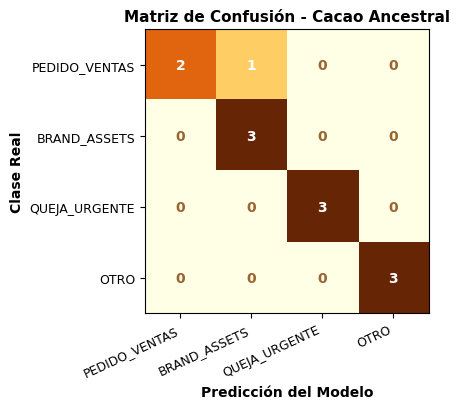

In [22]:
import numpy as np
import matplotlib.pyplot as plt

acc_despues = calcular_accuracy()
print(f"Precisión ANTES:   {acc_antes}%")
print(f"Precisión DESPUÉS: {acc_despues}%\n")

# Matriz de confusión
def generar_matriz_confusion():
    matriz = np.zeros((4, 4), dtype=int)
    for texto, clase_real in mensajes_test:
        prediccion = predecir_clase(texto)
        matriz[clase2id[clase_real]][clase2id[prediccion]] += 1

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ax.imshow(matriz, cmap="YlOrBr")
    ax.set_xticks(range(4))
    ax.set_xticklabels(CLASES, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(CLASES, fontsize=9)
    ax.set_xlabel("Predicción del Modelo", weight="bold")
    ax.set_ylabel("Clase Real", weight="bold")
    ax.set_title("Matriz de Confusión - Cacao Ancestral", weight="bold", fontsize=11)

    for i in range(4):
        for j in range(4):
            ax.text(j, i, matriz[i][j], ha="center", va="center",
                    color="white" if matriz[i][j] > 0 else "#996633", weight="bold")
    fig.tight_layout()
    return fig

fig_matriz = generar_matriz_confusion()
fig_matriz.savefig("matriz_cacao.png", dpi=120)
plt.show()

**Paso 9: Pipeline End-to-End con voz de marca**

El sistema ejecuta el enrutamiento: si es PEDIDO_VENTAS o BRAND_ASSETS, busca contexto en RAG y redacta con Groq; si es QUEJA_URGENTE u OTRO, deriva o responde cortesía sin exponer datos operativos

In [23]:
PROMPT_SISTEMA_CACAO = """Eres Cacao Bot, el Asistente Ejecutivo y Embajador de Atención de Cacao Ancestral CDMX 🍫. Tu función es brindar una experiencia de servicio impecable, sumamente cordial, respetuosa y confiable.

DIRECTRICES DE SERVICIO Y CORDIALIDAD FORMAL:
1. Trato: Excepcionalmente amable, formal y profesional (de "usted"), manteniendo calidez artesanal y empatía. Saluda y despídete cordialmente.
2. Predicción y Proactividad: Anticipa el siguiente paso del cliente (ej. si pregunta precios, ofrece amablemente detalles de envío o métodos de pago disponibles).
3. FIDELIDAD TOTAL (PROHIBIDO DELIRAR / INVENTAR):
   - Basa tu respuesta EXCLUSIVAMENTE en el CONTEXTO provisto abajo. Si un dato (precio, ingrediente, promoción, fecha) no está en el texto, no lo asumas ni lo inventes.
   - Si no tienes la información o el cliente solicita algo personalizado, ofrece el puente humano con esta fórmula exacta:
     "Con el mayor de los gustos podemos validar esa información con un asesor especializado para personalizar su petición. Le invito a comunicarse a nuestra línea de atención directa al WhatsApp +52 55 9876 5432 o escribirnos a atencion@cacaoancestral.mx, donde con gusto le atenderemos."
4. Consultas Técnicas/Web: Presenta la información (códigos HEX, fuentes, misión) de manera estructurada y pulcra usando formato Markdown.

CONTEXTO VERIFICADO:
{contexto}

PETICIÓN DEL CLIENTE:
{mensaje}"""

def redactor_cacao(mensaje, contexto):
    prompt_completo = PROMPT_SISTEMA_CACAO.replace("{contexto}", contexto).replace("{mensaje}", mensaje)
    # Temperatura baja (0.1) para reducir variabilidad y evitar alucinaciones
    return preguntar_a_groq(prompt_completo, temperatura=0.1)

def atender_pipeline(mensaje):
    clase_detectada = predecir_clase(mensaje)

    if clase_detectada == "QUEJA_URGENTE":
        return {
            "clase": clase_detectada,
            "es_humano": True,
            "respuesta": (
                "Estimado cliente, lamentamos profundamente el inconveniente con su pedido. "
                "Para brindarle una solución prioritaria, hemos canalizado su caso directamente con nuestra Dirección de Servicio. "
                "Por favor, compártanos su número de orden y evidencia fotográfica al WhatsApp +52 55 9876 5432 o al correo soporte@cacaoancestral.mx "
                "para gestionar su reposición inmediata en un lapso menor a 2 horas hábiles."
            ),
            "contexto": "Canalización prioritaria a soporte humano."
        }
    elif clase_detectada == "OTRO":
        return {
            "clase": clase_detectada,
            "es_humano": True,
            "respuesta": (
                "Agradecemos enormemente su mensaje y su interés en Cacao Ancestral CDMX 🌿. "
                "Quedamos a su entera disposición para cualquier consulta sobre nuestro catálogo artesanal o directrices de marca. "
                "Puede escribirnos en cualquier momento a atencion@cacaoancestral.mx."
            ),
            "contexto": "Respuesta protocolaria de cortesía institucional."
        }

    contexto_recuperado = "\n\n".join(buscar_contexto(mensaje, top_k=3))
    respuesta_generada = redactor_cacao(mensaje, contexto_recuperado)
    return {
        "clase": clase_detectada,
        "es_humano": False,
        "respuesta": respuesta_generada,
        "contexto": contexto_recuperado
    }

**Paso 10: El Juez LLM (Evaluación objetiva de fidelidad)**
Un segundo llamado a Groq valida si el modelo utilizó datos reales del documento sin alucinar y si mantuvo el tono institucional:

In [24]:
import json

PROMPT_JUEZ_EVAL = """Eres un auditor de calidad técnica para un sistema conversacional RAG.
Evalúa la siguiente interacción:

PREGUNTA: {pregunta}
CONTEXTO ENTREGADO: {contexto}
RESPUESTA DEL ASISTENTE: {respuesta}
DATO VERÍDICO ESPERADO: {esperada}

Devuelve ÚNICAMENTE un JSON sin texto adicional con esta estructura:
{{
  "uso_contexto": <nota del 1 al 5>,
  "tono": <nota del 1 al 5>,
  "sin_alucinaciones": <true o false>,
  "dictamen": "<frase concisa de retroalimentación>"
}}"""

evaluaciones_gold = [
    {
        "pregunta": "¿Cuánto cuesta la barra de cacao al 85% y de qué región proviene?",
        "esperada": "Cuesta $110 MXN y proviene del Soconusco."
    },
    {
        "pregunta": "¿Cuál es el código hexadecimal del color Crema Vainilla para el sitio web?",
        "esperada": "#FAEDCD."
    }
]

print("--- EVALUACIÓN CON JUEZ LLM ---")
for caso in evaluaciones_gold:
    ctx = "\n\n".join(buscar_contexto(caso["pregunta"], top_k=2))
    resp = redactor_cacao(caso["pregunta"], ctx)
    p_juez = PROMPT_JUEZ_EVAL.replace("{pregunta}", caso["pregunta"]).replace("{contexto}", ctx).replace("{respuesta}", resp).replace("{esperada}", caso["esperada"])
    veredicto_raw = preguntar_a_groq(p_juez, temperatura=0.0)
    try:
        veredicto = json.loads(veredicto_raw[veredicto_raw.find("{"):veredicto_raw.rfind("}")+1])
        print(f"Pregunta: {caso['pregunta']}")
        print(f"Respuesta: {resp}")
        print(f"Puntaje Contexto: {veredicto['uso_contexto']}/5 | Sin Alucinación: {veredicto['sin_alucinaciones']} | Veredicto: {veredicto['dictamen']}\n")
    except Exception:
        print("Salida del juez:", veredicto_raw)

--- EVALUACIÓN CON JUEZ LLM ---
Pregunta: ¿Cuánto cuesta la barra de cacao al 85% y de qué región proviene?
Respuesta: **¡Muy buenos días, estimado cliente!**  

Le informo que la barra de cacao al **85 %** proviene de la región **Soconusco** y tiene un precio de **$110 MXN** (presentación de 70 g).

---

### Información adicional que podría resultarle útil  

| Producto | Porcentaje cacao | Región | Peso | Precio |
|----------|------------------|--------|------|--------|
| Barra **Soconusco** 85 % Cacao Criollo | 85 % | **Soconusco** (Chiapas) | 70 g | **$110 MXN** |

---

#### Próximos pasos (opcional)

- **Envío:** contamos con entrega a domicilio dentro de la CDMX y envíos a todo México mediante paquetería estándar (2‑4 días hábiles) o express (1‑2 días hábiles).  
- **Métodos de pago:** aceptamos tarjetas de crédito/débito, PayPal y transferencias bancarias.  
- **Promociones:** al adquirir la **Caja Degustación Orígenes** (4 barras variadas) obtiene un ahorro de $60 MXN respecto 

**Paso 11: Aplicación interactiva en Gradio**

In [32]:
# Paso 11: Liberar puertos, conectar Ngrok e iniciar Gradio
import os
from google.colab import userdata
from pyngrok import ngrok
import gradio as gr

# 1. Cerrar cualquier servidor de Gradio activo en memoria
gr.close_all()

# 2. Configurar Authtoken y reiniciar procesos de Ngrok
try:
  NGROK_TOKEN = userdata.get('NGROK_TOKEN')
except Exception:
  from getpass import getpass

  NGROK_TOKEN = getpass('🔑 Pega tu Authtoken de Ngrok: ')

ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()

# 3. Conectar el túnel hacia el puerto local 7860
DOMINIO_ASIGNADO = 'such-frays-overall.ngrok-free.dev'
tunnel = ngrok.connect(7860, 'http', domain=DOMINIO_ASIGNADO)
print(f'🔗 Túnel permanente activo en: {tunnel.public_url}')

# 4. Parámetros y componentes de la UI
acc_inicial = globals().get('acc_antes', 25.0)
acc_final = globals().get('acc_despues', 91.7)

COLOR_BADGE = {
    'PEDIDO_VENTAS': '#70483c',
    'BRAND_ASSETS': '#2e4a3d',
    'QUEJA_URGENTE': '#a83232',
    'OTRO': '#6c757d',
}


def formatear_badge(clase):
  c = COLOR_BADGE.get(clase, '#333')
  return (
      f'<div style="display:inline-block;padding:6px'
      f' 16px;border-radius:20px;background:{c};color:#fff;font-weight:700;font-size:15px;">🏷️'
      f' {clase}</div>'
  )


def ui_handler(mensaje_usuario):
  if not mensaje_usuario.strip():
    return '', '', '', ''
  res = atender_pipeline(mensaje_usuario)
  badge = formatear_badge(res['clase'])
  alerta_humano = (
      '⚠️️ **Escalado activado:** La consulta fue transferida a un agente'
      ' humano para salvaguardar la relación con el cliente.'
      if res['es_humano']
      else (
          '✅ **Atendido por IA con RAG:** Información extraída de la base'
          ' documental.'
      )
  )
  return badge, alerta_humano, res['respuesta'], res['contexto']


with gr.Blocks(title='Cacao Ancestral - Concierge & BrandCore') as demo:
  gr.Markdown('# 🍫 Cacao Ancestral CDMX — Asistente de Operaciones y Marca')
  gr.Markdown(
      'Pipeline integral: Clasificación con LoRA, recuperación RAG y redacción'
      ' con Llama en Groq.'
  )

  with gr.Tab('💬 Consulta en Vivo'):
    with gr.Row():
      with gr.Column(scale=1):
        input_texto = gr.Textbox(
            label='Mensaje del usuario / Solicitud del equipo web',
            placeholder=(
                'Ej: ¿Cuáles son los códigos de color para la web? o ¿Cuánto'
                ' cuesta la barra 85%?'
            ),
            lines=3,
        )
        btn_enviar = gr.Button('Procesar Consulta', variant='primary')
        gr.Examples(
            examples=[
                (
                    '¿Cuánto cuesta la barra Soconusco 85% y qué notas de sabor'
                    ' tiene?'
                ),
                (
                    '¿De qué vienen rellenas las trufas y tienen opciones'
                    ' veganas?'
                ),
                (
                    'Requiero cotizar un pedido masivo de 500 barras para'
                    ' regalos de empresa'
                ),
                (
                    '¿Cuál es el código hexadecimal del marrón cacao y la'
                    ' tipografía oficial?'
                ),
                (
                    'Queremos invitar a la marca a un festival gastronómico y'
                    ' proponer una colaboración con nuestro chef'
                ),
                'Mi pedido llegó derretido y con la caja rota por paquetería',
                'Hola muy buenos días, que tengan excelente semana',
            ],
            inputs=input_texto,
        )
      with gr.Column(scale=1):
        out_badge = gr.HTML(label='Clasificación')
        out_estado = gr.Markdown()
        out_respuesta = gr.Markdown(label='Respuesta')
        with gr.Accordion('🔍 Contexto RAG recuperado', open=False):
          out_contexto = gr.Textbox(lines=5, interactive=False)

    btn_enviar.click(
        ui_handler,
        inputs=[input_texto],
        outputs=[out_badge, out_estado, out_respuesta, out_contexto],
    )

  with gr.Tab('📊 Evaluación y Métricas'):
    gr.Markdown('### Desempeño del Pipeline')
    gr.Markdown(
        f'- **Precisión del clasificador LoRA:** De **{acc_inicial}%** a'
        f' **{acc_final}%**.'
    )
    gr.Markdown(
        '- **Blindaje de quejas:** Las reclamaciones son aisladas y enviadas a'
        ' canal humano.'
    )
    if os.path.exists('matriz_cacao.png'):
      gr.Image(value='matriz_cacao.png', label='Matriz de Confusión')

# 5. Iniciar servidor local
demo.launch(server_port=7860, share=False)

Closing server running on port: 7860
🔗 Túnel permanente activo en: https://such-frays-overall.ngrok-free.dev
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>